# Curvas de LTV e Matriz de Retenção | 2023 até abril/2026

Este notebook busca dados reais no BigQuery e **não cria dados fictícios**.

**Objetivos:**
- Curva de LTV por **canal** (DIGITAL, NAC, UNIDADES)
- Curva de LTV por **subcanal** (Paid Search, Paid Social, Sites Monomarca, Search Organic, CRM)
- Curva de LTV por **marca**
- Curva de LTV por **grupo de exames**
- **Matriz de Retenção × LTV** para canal, subcanal, marca e grupo de exames

**Como ler a curva:** o eixo X mostra quantos meses se passaram desde a aquisição do paciente; o eixo Y mostra o LTV médio acumulado por paciente.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from google.cloud import bigquery
from google.cloud import bigquery_storage

## 1. Configuração

Parâmetros principais. A data final é **exclusiva**:  significa que os dados vão até abril/2026.

In [53]:
CANAIS_ANALISE    = ["DIGITAL", "NAC", "UNIDADES"]
SUBCANAIS_ANALISE = ["Paid Search", "Paid Social", "Sites Monomarca", "Search Organic", "CRM"]
GRUPOS_EXAMES    = ["AC", "RDI", "VACINA"]

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Marcas foco (lista que você passou) ---
MARCAS_FOCO = [
    "ALTA",
    "BORIS BERENSTEIN",
    "BRONSTEIN",
    "CDPI",
    "CERPE",
    "DELBONI",
    "EXAME",
    "FRISCHMANN AISENGART",
    "IMAGE MEMORIAL",
    "LAVOISIER",
    "LEME",
    "LUSTOSA",
    "SALOMAO E ZOPPI",
    "SANTA LUZIA",
    "SAO CAMILO",
    "SAO MARCOS",
    "SERGIO FRANCO",
]

# Normalização simples: trim + upper (resolve 80% dos "não bateu")
df["marca_norm"] = df["marca"].astype(str).str.strip().str.upper()
MARCAS_FOCO_NORM = [m.strip().upper() for m in MARCAS_FOCO]

# (Opcional) Se quiser checar quais não estão batendo:
faltando = sorted(set(MARCAS_FOCO_NORM) - set(df["marca_norm"].unique()))
if faltando:
    print("⚠️ Marcas foco não encontradas no df (após normalização):", faltando)

## 2. Query

A query faz quatro coisas:

1. Lê atendimentos de 2023 até abril/2026.
2. Determina a **coorte de aquisição**: primeiro mês em que o paciente aparece como .
3. Soma a receita de cada paciente por mês a partir da aquisição.
4. Calcula o **LTV acumulado por coorte**, particionando por canal, subcanal, marca e grupo de exames juntos.

**Correções em relação à versão anterior:**
-  agora é calculado a partir da , **sem marca/grupo_exames** na chave — evita explosão de linhas duplicadas e garante que o denominador do LTV seja o total de pacientes únicos da coorte.
-  é calculada particionando por , ,  **apenas** (sem marca/grupo_exames), refletindo a coorte real.
- As colunas  e  são transportadas como atributos do **atendimento** (receita), não da coorte — um mesmo paciente pode ter atendimentos em marcas e grupos diferentes ao longo do tempo.

In [ ]:
query = """
WITH base_eventos AS (
  SELECT
    nu_cpf_paciente                                       AS paciente_id,
    DATE_TRUNC(mes_atendimento, MONTH)                    AS mes_atendimento,
    COALESCE(origem_agd,     'Nao Identificado')          AS canal_aquisicao,
    COALESCE(channel_group,  'Nao Identificado')          AS subcanal_aquisicao,
    COALESCE(marca,          'Nao Identificado')          AS marca,
    COALESCE(grupo_exames,   'Nao Identificado')          AS grupo_exames,
    classificacao_paciente_dasa,
    receita
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE mes_atendimento >= DATE '2023-01-01'
    AND mes_atendimento  < DATE '2026-05-01'
    AND classificacao_paciente_dasa IN ('novo', 'recorrente', 'recuperado')
),

-- Coorte: primeiro mês em que o paciente foi classificado como 'novo'
-- A chave da coorte é (paciente_id, canal, subcanal) — sem marca/grupo,
-- pois o paciente pertence a UMA coorte independentemente de onde gasta.
coorte_aquisicao AS (
  SELECT
    paciente_id,
    mes_atendimento  AS mes_coorte,
    canal_aquisicao,
    subcanal_aquisicao
  FROM base_eventos
  WHERE classificacao_paciente_dasa = 'novo'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY paciente_id
    ORDER BY mes_atendimento ASC
  ) = 1
),

-- Tamanho da coorte: pacientes únicos por (canal, subcanal, mes_coorte)
tamanho_coorte AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    mes_coorte,
    COUNT(DISTINCT paciente_id) AS tamanho_coorte
  FROM coorte_aquisicao
  GROUP BY ALL
),

-- Receita mensal por paciente (soma de todos os atendimentos naquele mês)
receita_por_mes AS (
  SELECT
    paciente_id,
    mes_atendimento,
    -- Pega marca e grupo_exames do atendimento de MAIOR receita no mês
    -- (critério desempate: marca/grupo mais representativo do mês do paciente)
    ARRAY_AGG(marca        ORDER BY receita DESC LIMIT 1)[OFFSET(0)] AS marca,
    ARRAY_AGG(grupo_exames ORDER BY receita DESC LIMIT 1)[OFFSET(0)] AS grupo_exames,
    SUM(receita) AS receita_mes
  FROM base_eventos
  GROUP BY paciente_id, mes_atendimento
),

-- Junta coorte com receita e calcula mês relativo
coorte_receita AS (
  SELECT
    c.paciente_id,
    c.mes_coorte,
    c.canal_aquisicao,
    c.subcanal_aquisicao,
    r.mes_atendimento,
    r.marca,
    r.grupo_exames,
    DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) AS mes_desde_aquisicao,
    r.receita_mes
  FROM coorte_aquisicao c
  INNER JOIN receita_por_mes r
    ON  r.paciente_id   = c.paciente_id
    AND r.mes_atendimento >= c.mes_coorte
),

-- Agrega por (canal, subcanal, marca, grupo_exames, coorte, mes_relativo)
receita_mensal AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    marca,
    grupo_exames,
    mes_coorte,
    mes_atendimento,
    mes_desde_aquisicao,
    COUNT(DISTINCT paciente_id) AS pacientes_ativos,
    SUM(receita_mes)            AS receita_mes
  FROM coorte_receita
  GROUP BY ALL
),

-- Receita acumulada particionada por (canal, subcanal, mes_coorte)
-- Nota: marca e grupo_exames ficam como atributos do atendimento
base_final AS (
  SELECT
    r.canal_aquisicao,
    r.subcanal_aquisicao,
    r.marca,
    r.grupo_exames,
    r.mes_coorte,
    r.mes_atendimento,
    r.mes_desde_aquisicao,
    r.pacientes_ativos,
    c.tamanho_coorte,
    r.receita_mes,
    SUM(r.receita_mes) OVER (
      PARTITION BY r.canal_aquisicao, r.subcanal_aquisicao, r.mes_coorte
      ORDER BY r.mes_desde_aquisicao
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS receita_acumulada
  FROM receita_mensal r
  LEFT JOIN tamanho_coorte c
    ON  r.canal_aquisicao    = c.canal_aquisicao
    AND r.subcanal_aquisicao = c.subcanal_aquisicao
    AND r.mes_coorte         = c.mes_coorte
)

SELECT
  canal_aquisicao,
  subcanal_aquisicao,
  marca,
  grupo_exames,
  mes_coorte,
  mes_atendimento,
  mes_desde_aquisicao,
  pacientes_ativos,
  tamanho_coorte,
  ROUND(receita_mes,         2) AS receita_mes,
  ROUND(receita_acumulada,   2) AS receita_acumulada,
  ROUND(receita_acumulada / NULLIF(tamanho_coorte, 0), 2) AS ltv_medio_por_paciente
FROM base_final
ORDER BY canal_aquisicao, subcanal_aquisicao, mes_coorte, mes_desde_aquisicao
"""

## 3. Carregar dados

Executa a query no BigQuery. Se der erro aqui, o problema está em permissão, autenticação, nome da tabela ou nome de alguma coluna.

In [4]:
client          = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()

df = client.query(query).result().to_dataframe(bqstorage_client=bqstorage_client)

df["mes_coorte"]          = pd.to_datetime(df["mes_coorte"])
df["mes_atendimento"]     = pd.to_datetime(df["mes_atendimento"])
df["mes_desde_aquisicao"] = df["mes_desde_aquisicao"].astype(int)

print(f"Linhas carregadas : {len(df):,}")
print(f"Coortes           : {df['mes_coorte'].min().date()} → {df['mes_coorte'].max().date()}")
print(f"Atendimentos      : {df['mes_atendimento'].min().date()} → {df['mes_atendimento'].max().date()}")
print()
print("Canais únicos     :", df["canal_aquisicao"].unique().tolist())
print("Subcanais únicos  :", df["subcanal_aquisicao"].unique().tolist())
print("Marcas únicas     :", df["marca"].nunique(), "marcas")
print("Grupos de exames  :", df["grupo_exames"].nunique(), "grupos")
df.head()

Linhas carregadas : 282,234
Coortes           : 2023-01-01 → 2026-04-01
Atendimentos      : 2023-01-01 → 2026-04-01

Canais únicos     : ['DIGITAL', 'NAC', 'UNIDADES']
Subcanais únicos  : ['Blog', 'CRM', 'Dial My App', 'Direto', 'Fluxos NAC', 'IAs', 'Nao Identificado', 'Organic Social', 'Outros', 'Paid Search', 'Paid Social', 'QR Code', 'Referral', 'Search Organic', 'Sites Monomarca']
Marcas únicas     : 47 marcas
Grupos de exames  : 6 grupos


,canal_aquisicao,subcanal_aquisicao,marca,grupo_exames,mes_coorte,mes_atendimento,mes_desde_aquisicao,pacientes_ativos,tamanho_coorte,receita_mes,receita_acumulada,ltv_medio_por_paciente
0,DIGITAL,Blog,DELBONI,AC,2025-07-01,2025-07-01,0,2,3,284.02,284.02,94.67
1,DIGITAL,Blog,DELBONI,RDI,2025-07-01,2025-07-01,0,1,3,21.08,305.10,101.70
2,DIGITAL,Blog,LAVOISIER,AC,2025-08-01,2025-08-01,0,4,18,401.33,401.33,22.30
3,DIGITAL,Blog,LAVOISIER,RDI,2025-08-01,2025-08-01,0,2,18,562.91,964.24,53.57
4,DIGITAL,Blog,LAVOISIER,VACINA,2025-08-01,2025-08-01,0,1,18,139.00,1103.24,61.29


## 4. Funções de agregação e gráfico

Todas as transformações partem do dataframe carregado acima — nenhum dado novo é buscado.

**LTV acumulado médio:** soma da  das coortes ÷ soma do  das coortes (média ponderada).

In [41]:
# ── Formatação BR ─────────────────────────────────────────────────────────────
def formatar_reais(valor: float) -> str:
    """Formata número como moeda BR: R$ 1.234"""
    return f"R$ {valor:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")


# ── Curva LTV ──────────────────────────────────────────────────────────────────
def agregar_curva_ltv(
    df_base: pd.DataFrame,
    coluna_grupo: str,
    grupos: list[str]
) -> pd.DataFrame:
    """
    Calcula o LTV acumulado médio por mês relativo à aquisição.
    Usa receita_acumulada do SQL diretamente (já cumulativa por coorte).
    Média ponderada pelo tamanho de cada coorte.
    """
    df_plot = df_base[df_base[coluna_grupo].isin(grupos)].copy()
    if df_plot.empty:
        print(f"Nenhum dado para {coluna_grupo}: {grupos}")
        return df_plot

    mensal = (
        df_plot
        .groupby([coluna_grupo, "mes_desde_aquisicao"], as_index=False)
        .agg(
            receita_acumulada_total=("receita_acumulada", "sum"),
            pacientes=("tamanho_coorte", "sum"),
        )
    )
    mensal["ltv_acumulado"] = mensal["receita_acumulada_total"] / mensal["pacientes"]
    return mensal


def plotar_curva(
    df_curva: pd.DataFrame,
    coluna_grupo: str,
    grupos: list[str],
    titulo: str,
    caminho_saida: Path,
    max_meses: int | None = 24,          # <- limita janela (ex.: 24 meses) pra não esticar
    usar_quantile_y: bool = True,        # <- evita outlier explodir eixo
    q_inf: float = 0.02,
    q_sup: float = 0.98
) -> None:
    if df_curva.empty:
        return

    # Limita meses se necessário
    df_plot = df_curva.copy()
    if max_meses is not None:
        df_plot = df_plot[df_plot["mes_desde_aquisicao"] <= max_meses]

    # Ajusta tamanho em função do número de séries
    n_series = len(grupos)
    fig_h = min(10, 6 + 0.25 * max(0, n_series - 5))
    fig, ax = plt.subplots(figsize=(17, fig_h))

    # Plota
    for grupo in grupos:
        dados = df_plot[df_plot[coluna_grupo] == grupo].sort_values("mes_desde_aquisicao")
        if dados.empty:
            continue

        ax.plot(
            dados["mes_desde_aquisicao"],
            dados["ltv_acumulado"],
            marker="o",
            markersize=4,
            linewidth=2.2,
            label=grupo,
        )

    # Eixos / limites
    max_mes = int(df_plot["mes_desde_aquisicao"].max()) if not df_plot.empty else 0
    ax.set_xlim(0, max_mes + 1)

    # Controle de outliers no eixo Y (evita “explodido”)
    if usar_quantile_y and df_plot["ltv_acumulado"].notna().any():
        y0 = df_plot["ltv_acumulado"].quantile(q_inf)
        y1 = df_plot["ltv_acumulado"].quantile(q_sup)
        pad = (y1 - y0) * 0.08 if y1 > y0 else (y1 * 0.1 if y1 else 1)
        ax.set_ylim(max(0, y0 - pad), y1 + pad)

    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Meses desde a aquisição")
    ax.set_ylabel("LTV médio por paciente")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formatar_reais(x)))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", alpha=0.15)

    # Legenda: se tiver muita série, compacta
    if n_series <= 10:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
        plt.tight_layout()

    plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
plt.show()

## Matriz Retenção × LTV

A matriz posiciona cada segmento em dois eixos:
- **Eixo X** — taxa de retenção no mês de referência (pacientes ainda ativos ÷ tamanho original da coorte)
- **Eixo Y** — LTV acumulado médio até o mês de referência

O tamanho do ponto é proporcional ao volume de pacientes adquiridos.

**Correção em relação à versão anterior:** a função agora filtra corretamente apenas as coortes que já completaram o  (coortes *elegíveis*), evitando sub-estimativa de retenção em coortes jovens.

In [44]:
def criar_matriz_retencao_ltv(
    df_base,
    coluna_grupo: str,
    grupos=None,
    mes_referencia: int = 12
) -> pd.DataFrame:
    """
    Calcula LTV acumulado e taxa de retenção no mes_referencia para cada grupo.

    Retorna um DataFrame com colunas:
    <coluna_grupo>, ltv_final, retencao, volume_pacientes, coortes_elegiveis, mes_referencia.
    """
    df_m = df_base.copy()
    if grupos is not None:
        df_m = df_m[df_m[coluna_grupo].isin(grupos)].copy()

    if df_m.empty:
        print("Base vazia após filtro.")
        return pd.DataFrame()

    data_fim = df_m["mes_atendimento"].max()
    resultados = []

    for grupo, g in df_m.groupby(coluna_grupo):

        # Identifica coortes elegíveis (já completaram mes_referencia)
        coortes_info = (
            g[["canal_aquisicao", "subcanal_aquisicao", "mes_coorte", "tamanho_coorte"]]
            .drop_duplicates()
        )

        coortes_info = coortes_info.assign(
            idade_meses=(
                (data_fim.year - coortes_info["mes_coorte"].dt.year) * 12
                + (data_fim.month - coortes_info["mes_coorte"].dt.month)
            )
        )

        elegiveis = coortes_info[coortes_info["idade_meses"] >= mes_referencia].copy()
        volume_total = coortes_info["tamanho_coorte"].sum()

        if elegiveis.empty:
            resultados.append({
                coluna_grupo: grupo,
                "ltv_final": np.nan,
                "retencao": np.nan,
                "volume_pacientes": volume_total,
                "coortes_elegiveis": 0,
                "mes_referencia": mes_referencia,
            })
            continue

        chave_coorte = ["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"]
        g_eleg = g.merge(elegiveis[chave_coorte], on=chave_coorte, how="inner")

        # Linhas no mes_referencia
        g_mes = g_eleg[g_eleg["mes_desde_aquisicao"] == mes_referencia].copy()
        tamanho_eleg = elegiveis["tamanho_coorte"].sum()

        if g_mes.empty or tamanho_eleg <= 0:
            ltv = np.nan
            retencao = np.nan
        else:
            ltv = g_mes["receita_acumulada"].sum() / tamanho_eleg
            retencao = g_mes["pacientes_ativos"].sum() / tamanho_eleg

        resultados.append({
            coluna_grupo: grupo,
            "ltv_final": ltv,
            "retencao": retencao,
            "volume_pacientes": volume_total,
            "coortes_elegiveis": len(elegiveis),
            "mes_referencia": mes_referencia,
        })

    return pd.DataFrame(resultados)


def plotar_matriz(
    df_matriz: pd.DataFrame,
    coluna_grupo: str,
    titulo: str,
    caminho_saida: Path = None
) -> None:
    """Plota a Matriz Retenção × LTV com quadrantes (robusta no VS Code)."""

    # Sempre cria a figura (mesmo se não houver dados válidos)
    fig, ax = plt.subplots(figsize=(14, 8))

    # Filtra pontos válidos
    dados = df_matriz.dropna(subset=["ltv_final", "retencao"]).copy()

    # Caso não tenha ponto válido: mostra mensagem no próprio gráfico
    if dados.empty:
        ax.axis("off")
        ax.text(
            0.5, 0.5,
            "Sem dados suficientes para plotar a matriz.\n"
            "Verifique se existem coortes elegíveis no mês de referência\n"
            "e se ltv_final/retencao não estão NaN.",
            ha="center", va="center",
            fontsize=12, fontweight="bold",
            transform=ax.transAxes
        )
        ax.set_title(titulo, fontsize=15, fontweight="bold", pad=15)
        plt.tight_layout()

        if caminho_saida:
            plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
            print(f"Imagem salva: {caminho_saida}")

        plt.show()
        plt.close(fig)
        return

    # Cortes (medianas)
    corte_ltv = dados["ltv_final"].median()
    corte_retencao = dados["retencao"].median()

    # Tamanho das bolhas (safe)
    vol_max = dados["volume_pacientes"].max()
    if pd.isna(vol_max) or vol_max <= 0:
        tamanhos = np.full(len(dados), 250.0)
    else:
        tamanhos = (dados["volume_pacientes"] / vol_max) * 1800

    ax.scatter(
        dados["retencao"],
        dados["ltv_final"],
        s=tamanhos,
        alpha=0.6,
        edgecolor="black",
        linewidth=1.2,
    )

    # Labels dos pontos
    for _, row in dados.iterrows():
        ax.annotate(
            str(row[coluna_grupo]),
            xy=(row["retencao"], row["ltv_final"]),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            clip_on=True
        )

    # Linhas de corte
    ax.axvline(corte_retencao, linestyle="--", linewidth=1.5, color="#1976d2", alpha=0.8)
    ax.axhline(corte_ltv,      linestyle="--", linewidth=1.5, color="#1976d2", alpha=0.8)

    # Quadrantes (posição fixa no eixo)
    quadrantes = [
        (0.02, 0.02, "⬇ Rever aquisição\nRetenção baixa + LTV baixo"),
        (0.52, 0.02, "⬆ Fidelizados pouco rentáveis\nRetenção alta + LTV baixo"),
        (0.02, 0.52, "★ Nicho premium\nRetenção baixa + LTV alto"),
        (0.52, 0.52, "✦ Clientes ideais\nRetenção alta + LTV alto"),
    ]

    for xq, yq, label in quadrantes:
        ax.text(
            xq, yq, label,
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.65,
            fontstyle="italic",
            va="bottom",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.55,
                edgecolor="none"
            ),
            clip_on=True
        )

    # Títulos/eixos
    mes_ref = int(dados["mes_referencia"].iloc[0])
    ax.set_title(f"{titulo} | Mês {mes_ref}", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(f"Retenção no mês {mes_ref}", fontsize=12)
    ax.set_ylabel("LTV acumulado médio por paciente", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formatar_reais(x)))
    ax.grid(alpha=0.25)

    plt.tight_layout()

    # Salva (se pediu)
    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")

    # Mostra sempre (VS Code / Jupyter)
    plt.show()
    plt.close(fig)

## 10. Matriz Retenção × LTV por Canal

,canal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,DIGITAL,4.417710e+05,0.061281,485617,311,12
1,NAC,1.046168e+06,0.053644,1142364,28,12
2,UNIDADES,7.866862e+05,0.059481,4945201,28,12


Imagem salva: outputs\matriz_retencao_canal_mes12.png


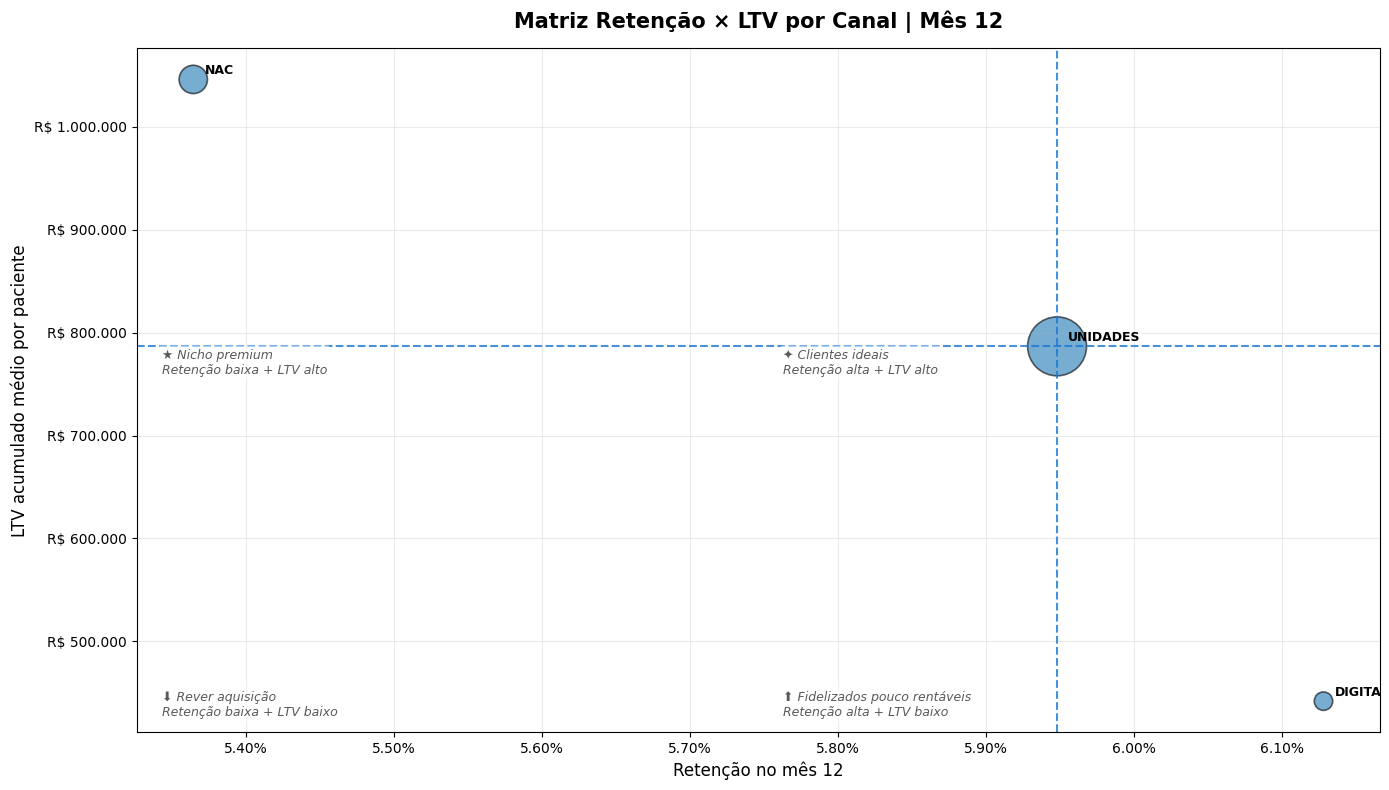

In [45]:
MES_REFERENCIA = 12

matriz_canais = criar_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="canal_aquisicao",
    grupos=CANAIS_ANALISE,
    mes_referencia=MES_REFERENCIA,
)
display(matriz_canais)

plotar_matriz(
    matriz_canais,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção × LTV por Canal",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_canal_mes{MES_REFERENCIA}.png",
)

## 11. Matriz Retenção × LTV por Subcanal

,subcanal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,CRM,122720.363993,0.062990,12108,28,12
1,Paid Search,391433.902922,0.058225,112205,28,12
2,Paid Social,3166.810493,0.023474,525,24,12
3,Search Organic,282456.638701,0.069278,30392,28,12
4,Sites Monomarca,445188.091215,0.055782,116533,28,12


Imagem salva: outputs\matriz_retencao_subcanal_mes12.png


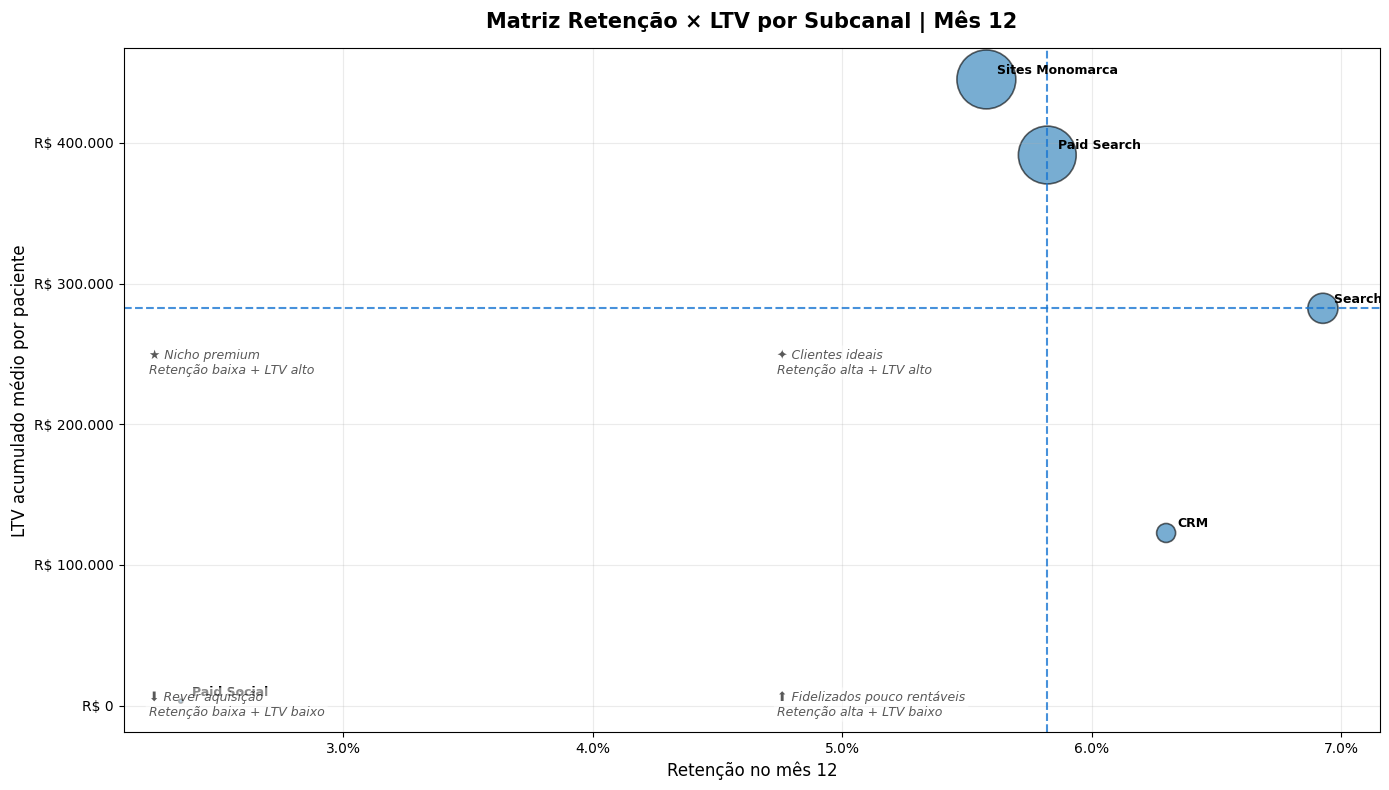

In [56]:
matriz_subcanais = criar_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="subcanal_aquisicao",
    grupos=SUBCANAIS_ANALISE,
    mes_referencia=MES_REFERENCIA,
)
display(matriz_subcanais)

plotar_matriz(
    matriz_subcanais,
    coluna_grupo="subcanal_aquisicao",
    titulo="Matriz Retenção × LTV por Subcanal",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_subcanal_mes{MES_REFERENCIA}.png",
)

## 12. Matriz Retenção × LTV por Marca

,marca,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,ALTA,40746.948242,0.001839,6572171,298,12
1,BORIS BERENSTEIN,4240.277795,0.000306,6530746,194,12
2,BRONSTEIN,39772.435512,0.004358,6572674,328,12
3,CDPI,9104.316741,0.000737,6565888,256,12
4,CERPE,28768.517205,0.001833,6570045,292,12
5,DELBONI,40511.430716,0.005390,6572927,334,12
6,EXAME,37875.610962,0.002357,6563106,300,12
7,FRISCHMANN AISENGART,28723.597633,0.001839,6571090,293,12
8,IMAGE MEMORIAL,23505.706249,0.000740,6570090,269,12
9,LAVOISIER,40816.282762,0.007238,6573064,344,12


Imagem salva: outputs\matriz_retencao_marca_foco_mes12.png


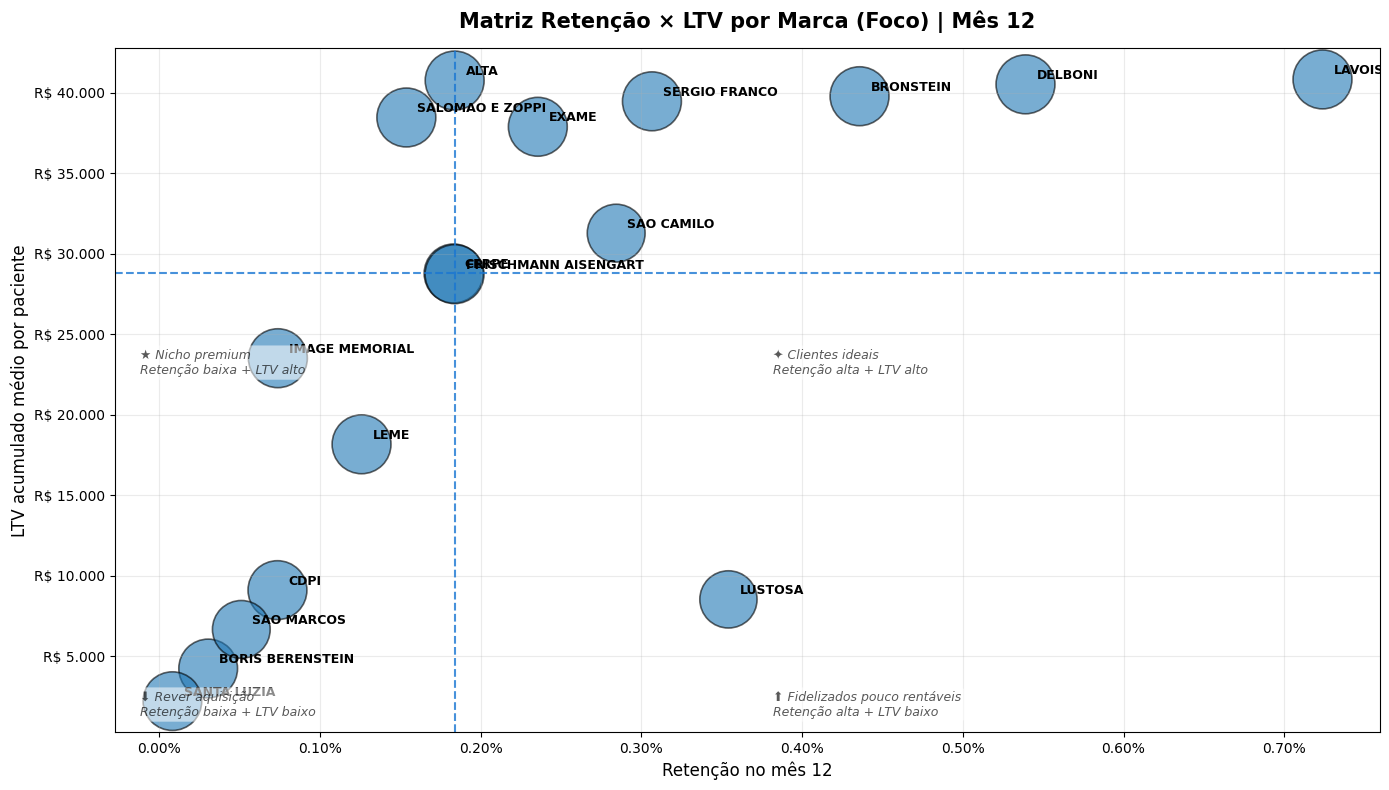

In [46]:
# --- Seção 12: Matriz Retenção × LTV por Marca (somente marcas foco) ---

df_marca = df.copy()
df_marca["marca"] = df_marca["marca"].astype(str).str.strip().str.upper()

matriz_marcas = criar_matriz_retencao_ltv(
    df_base=df_marca,
    coluna_grupo="marca",
    grupos=MARCAS_FOCO_NORM,          # <-- filtro só aqui
    mes_referencia=MES_REFERENCIA,
)
display(matriz_marcas)

plotar_matriz(
    matriz_marcas,
    coluna_grupo="marca",
    titulo="Matriz Retenção × LTV por Marca (Foco)",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_marca_foco_mes{MES_REFERENCIA}.png",
)

## 13. Matriz Retenção × LTV por Grupo de Exames

,grupo_exames,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,AC,271495.652122,0.044195,6573167,363,12
1,AP,145838.199505,0.001822,6571330,301,12
2,ASSINATURA,2391.378077,0.000006,6371899,127,12
3,OUTROS,76172.150718,0.000255,6553313,244,12
4,RDI,143932.837867,0.009676,6573123,348,12
5,VACINA,164926.827467,0.002686,6572342,305,12


Imagem salva: outputs\matriz_retencao_grupo_exames_mes12.png


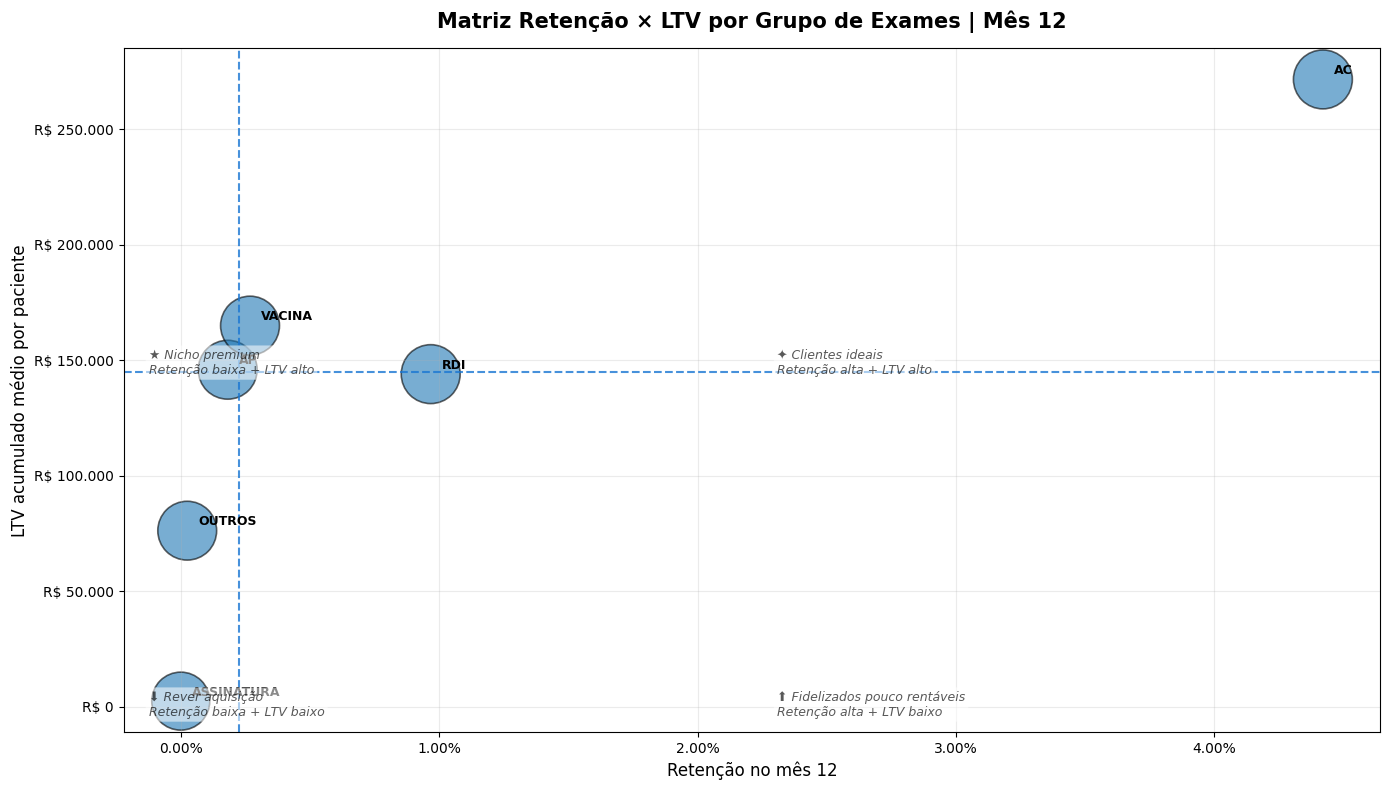

In [55]:
matriz_grupos = criar_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="grupo_exames",
    # grupos=GRUPOS_EXAMES,
    mes_referencia=MES_REFERENCIA,
)
display(matriz_grupos)

plotar_matriz(
    matriz_grupos,
    coluna_grupo="grupo_exames",
    titulo="Matriz Retenção × LTV por Grupo de Exames",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_grupo_exames_mes{MES_REFERENCIA}.png",
)

## 14. Resumo: Ticket Médio, Frequência Anual e Retenção por Canal

Fórmula de decomposição do LTV: **LTV = Ticket Médio × Frequência Anual × Retenção (anos)**

In [20]:
resultados = []

for canal in CANAIS_ANALISE:
    g = df[df["canal_aquisicao"] == canal].copy()
    if g.empty:
        continue

    tamanho_total = (
        g.drop_duplicates("mes_coorte")
         .groupby("mes_coorte")["tamanho_coorte"]
         .first()
         .sum()
    )
    janela_meses  = g["mes_desde_aquisicao"].max()
    janela_anos   = janela_meses / 12

    receita_total      = g["receita_mes"].sum()
    total_atendimentos = g["pacientes_ativos"].sum()

    ticket_medio     = receita_total / total_atendimentos if total_atendimentos > 0 else 0
    frequencia_anual = (total_atendimentos / tamanho_total) if (tamanho_total > 0 and janela_anos > 0) else 0

    ultimo_mes_por_coorte = (
        g.groupby("mes_coorte")
         .agg(ultimo_mes=("mes_desde_aquisicao", "max"),
              tamanho_coorte=("tamanho_coorte", "first"))
         .reset_index()
    )
    retencao_anos = np.average(
        ultimo_mes_por_coorte["ultimo_mes"],
        weights=ultimo_mes_por_coorte["tamanho_coorte"]
    ) / 12

    resultados.append({
        "CANAL"           : canal,
        "TICKET MÉDIO"    : ticket_medio,
        "FREQUÊNCIA ANUAL": frequencia_anual,
        "RETENÇÃO (anos)" : retencao_anos,
        "LTV (validação)" : ticket_medio * frequencia_anual * retencao_anos,
    })

tabela = pd.DataFrame(resultados).set_index("CANAL")
fmt = tabela.copy()
fmt["TICKET MÉDIO"]     = tabela["TICKET MÉDIO"].apply(formatar_reais)
fmt["FREQUÊNCIA ANUAL"] = tabela["FREQUÊNCIA ANUAL"].apply(lambda v: f"{v:.1f}x/ano")
fmt["RETENÇÃO (anos)"]  = tabela["RETENÇÃO (anos)"].apply(lambda v: f"{v:.1f} anos")
fmt["LTV (validação)"]  = tabela["LTV (validação)"].apply(formatar_reais)
display(fmt)

,TICKET MÉDIO,FREQUÊNCIA ANUAL,RETENÇÃO (anos),LTV (validação)
CANAL,,,,
DIGITAL,R$ 6.704,190.3x/ano,1.5 anos,R$ 1.931.016
NAC,R$ 6.456,2.0x/ano,1.5 anos,R$ 18.960
UNIDADES,R$ 3.688,2.0x/ano,1.6 anos,R$ 11.504
